# Week 1: Baseline ML Classifiers
**Project:** Tabular Data Labeling with LLM Reasoning: Nemotron Nano vs Traditional ML  
**Dataset:** Nemotron-Personas-USA (NVIDIA) → `nvidia/Nemotron-Personas-USA`  
**Task:** Binary classification → predict whether a person is college-educated (1) or not (0)  
**Features:** `age`, `sex`, `marital_status`, `occupation`, `state`  
**Label:** `education_level` → college (bachelors / graduate) or not_college

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from datasets import load_dataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import xgboost as xgb

print("Libraries imported successfully.")
print(f'pandas {pd.__version__}, numpy {np.__version__}')

Libraries imported successfully.
pandas 3.0.3, numpy 2.4.4


## 2. Load the Dataset

In [2]:
print("Loading dataset Nemotron-Personas-USA from Hugging Face")
print("This first run downloads the dataset, which is about 2.7 GB")

ds = load_dataset("nvidia/Nemotron-Personas-USA")
df_full = ds["train"].to_pandas()

print(f"\nFull dataset shape: {df_full.shape}")
print(f"Columns: {list(df_full.columns)}")

Loading dataset Nemotron-Personas-USA from Hugging Face
This first run downloads the dataset, which is about 2.7 GB

Full dataset shape: (1000000, 23)
Columns: ['uuid', 'professional_persona', 'sports_persona', 'arts_persona', 'travel_persona', 'culinary_persona', 'persona', 'cultural_background', 'skills_and_expertise', 'skills_and_expertise_list', 'hobbies_and_interests', 'hobbies_and_interests_list', 'career_goals_and_ambitions', 'sex', 'age', 'marital_status', 'education_level', 'bachelors_field', 'occupation', 'city', 'state', 'zipcode', 'country']


## 3. Select Features and Create Label

In [3]:
FEATURES = ["age", "sex", "marital_status", "occupation", "state"]
TARGET   = "education_level"

df = df_full[FEATURES + [TARGET]].copy()

print("education_level unique values:")
print(df[TARGET].value_counts())
print(f"\nTotal rows: {len(df):,}")

education_level unique values:
education_level
less_than_9th          251677
high_school            212908
some_college           165909
bachelors              158158
graduate                95110
associates              66209
9th_12th_no_diploma     50029
Name: count, dtype: int64

Total rows: 1,000,000


In [4]:
# Define the binary label: college = bachelors and above, non-college = everything else
COLLEGE = {"associates", "bachelors", "graduate"}

df["label"]      = df[TARGET].apply(lambda x: 1 if x in COLLEGE else 0)
df["label_name"] = df["label"].map({1: "college", 0: "not_college"})

print("education_level unique values:")
print(df[TARGET].value_counts())
print("\nBinary label distribution:")
print(df["label_name"].value_counts())
print(f"\nClass balance: {df['label_name'].value_counts(normalize=True).round(3).to_dict()}")

education_level unique values:
education_level
less_than_9th          251677
high_school            212908
some_college           165909
bachelors              158158
graduate                95110
associates              66209
9th_12th_no_diploma     50029
Name: count, dtype: int64

Binary label distribution:
label_name
not_college    680523
college        319477
Name: count, dtype: int64

Class balance: {'not_college': 0.681, 'college': 0.319}


## 4. EDA

C:\Users\javib\AppData\Local\Temp\ipykernel_42384\294662031.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_counts, x="label", y="count",


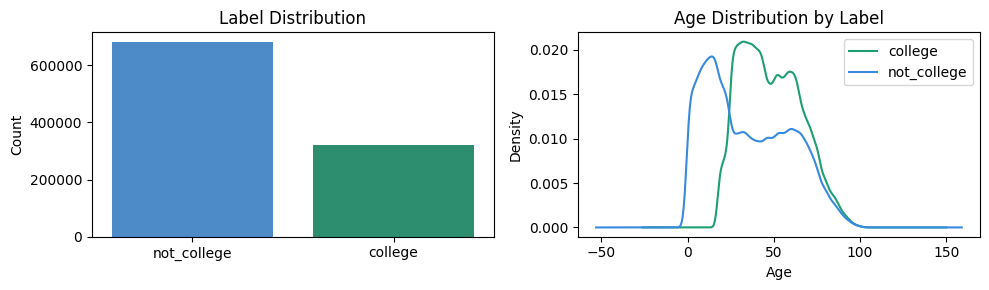

Saved: results/label_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Label distribution
label_counts = df["label_name"].value_counts().reset_index()
label_counts.columns = ["label", "count"]
sns.barplot(data=label_counts, x="label", y="count",
            palette=["#378ADD", "#1D9E75"], ax=axes[0])
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")

# Age distribution by label
for label, color in zip(["college", "not_college"], ["#1D9E75", "#378ADD"]):
    subset = df[df["label_name"] == label]["age"]
    subset.plot(kind="kde", ax=axes[1], label=label, color=color)
axes[1].set_title("Age Distribution by Label")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
os.makedirs("../results", exist_ok=True)
plt.savefig("../results/label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/label_distribution.png")

In [6]:
# Top occupations by class (Nemotron's reasoning)
print("Top 10 occupations — college class:")
print(df[df["label"]==1]["occupation"].value_counts().head(10))
print("\nTop 10 occupations — not_college class:")
print(df[df["label"]==0]["occupation"].value_counts().head(10))

Top 10 occupations — college class:
occupation
not_in_workforce                                70549
software_developer                               7881
manager                                          7372
elementary_or_middle_school_teacher              7201
accountant_or_auditor                            5850
first_line_supervisor_of_retail_sales_worker     4873
no_occupation                                    4735
retail_salesperson                               3931
cashier                                          3917
postsecondary_teacher                            3883
Name: count, dtype: int64

Top 10 occupations — not_college class:
occupation
not_in_workforce                              364195
no_occupation                                  12745
driver_sales_worker_or_truck_driver             9141
customer_service_representative                 8388
retail_salesperson                              7722
cashier                                         7210
construction_labo

In [7]:
print(f"Unique occupations: {df['occupation'].nunique()}")
print(f"Unique states:      {df['state'].nunique()}")
print(f"Sex values:         {sorted(df['sex'].unique())}")
print(f"Marital status:     {sorted(df['marital_status'].unique())}")

Unique occupations: 567
Unique states:      52
Sex values:         ['Female', 'Male']
Marital status:     ['divorced', 'married_present', 'never_married', 'separated', 'widowed']


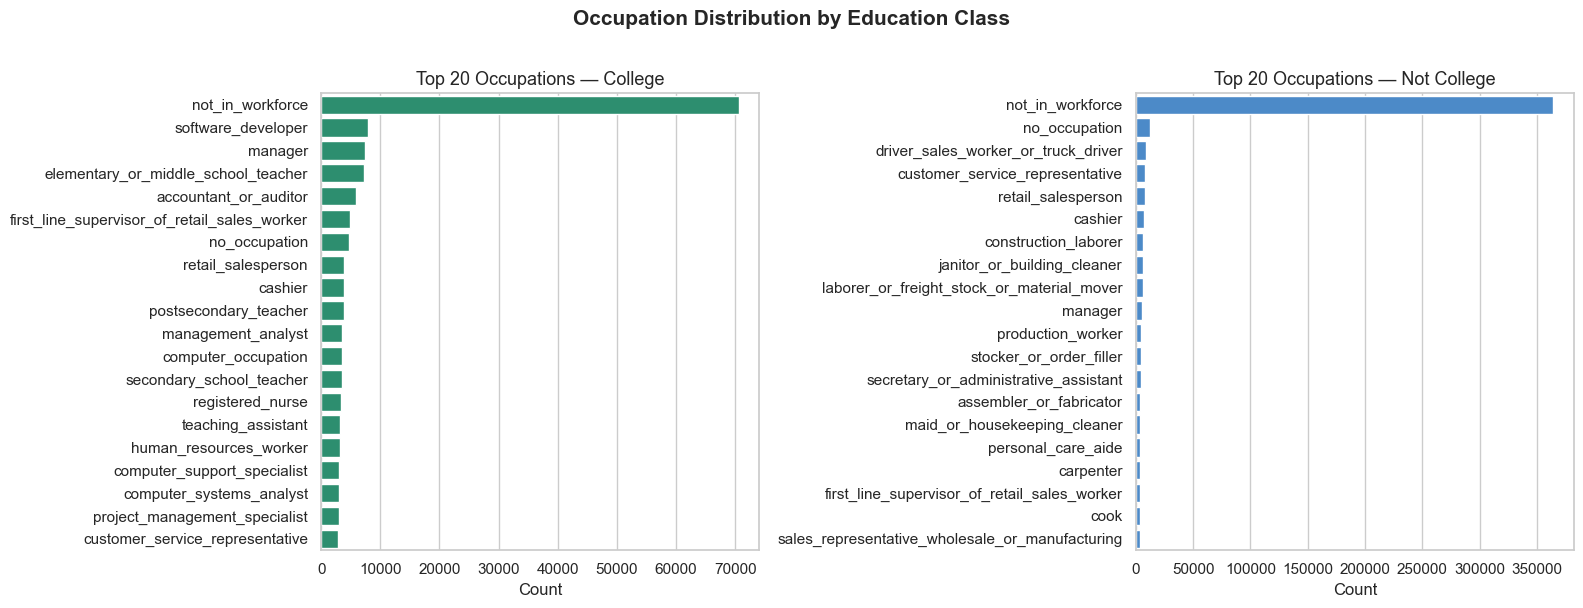

Saved: results/occupation_by_class.png


In [8]:
# Top 20 occupations by education class
sns.set_theme(style="whitegrid")

top_college = (df[df["label_name"] == "college"]["occupation"]
               .value_counts().head(20).reset_index())
top_college.columns = ["occupation", "count"]

top_not = (df[df["label_name"] == "not_college"]["occupation"]
           .value_counts().head(20).reset_index())
top_not.columns = ["occupation", "count"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_college, x="count", y="occupation",
            color="#1D9E75", ax=axes[0])
axes[0].set_title("Top 20 Occupations — College", fontsize=13)
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

sns.barplot(data=top_not, x="count", y="occupation",
            color="#378ADD", ax=axes[1])
axes[1].set_title("Top 20 Occupations — Not College", fontsize=13)
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.suptitle("Occupation Distribution by Education Class",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../results/occupation_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/occupation_by_class.png")

C:\Users\javib\AppData\Local\Temp\ipykernel_42384\409207422.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_stats, x="college_rate", y="state",


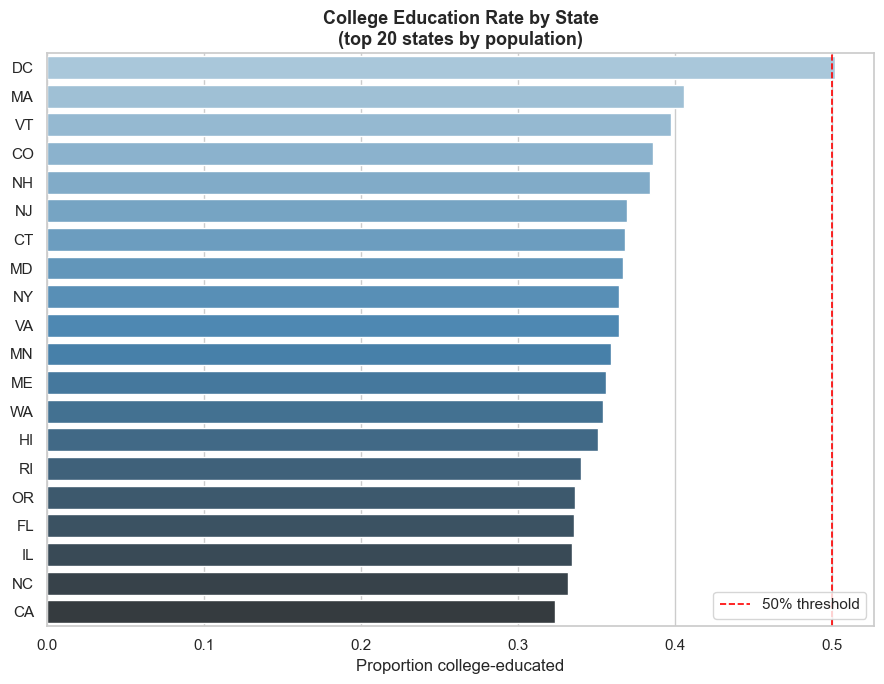

Saved: results/college_rate_by_state.png


In [9]:
# College rate by state (top 20 most populous states in dataset)
state_stats = df.groupby("state")["label"].agg(["mean", "count"]).reset_index()
state_stats.columns = ["state", "college_rate", "count"]
state_stats = (state_stats[state_stats["count"] > 1000]
               .sort_values("college_rate", ascending=False)
               .head(20))

fig, ax = plt.subplots(figsize=(9, 7))

sns.barplot(data=state_stats, x="college_rate", y="state",
            palette="Blues_d", ax=ax)
ax.axvline(x=0.5, color="red", linestyle="--",
           linewidth=1.2, label="50% threshold")
ax.set_title("College Education Rate by State\n(top 20 states by population)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion college-educated")
ax.set_ylabel("")
ax.legend()

plt.tight_layout()
plt.savefig("../results/college_rate_by_state.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/college_rate_by_state.png")

C:\Users\javib\AppData\Local\Temp\ipykernel_42384\225376529.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="education_level", y="age",


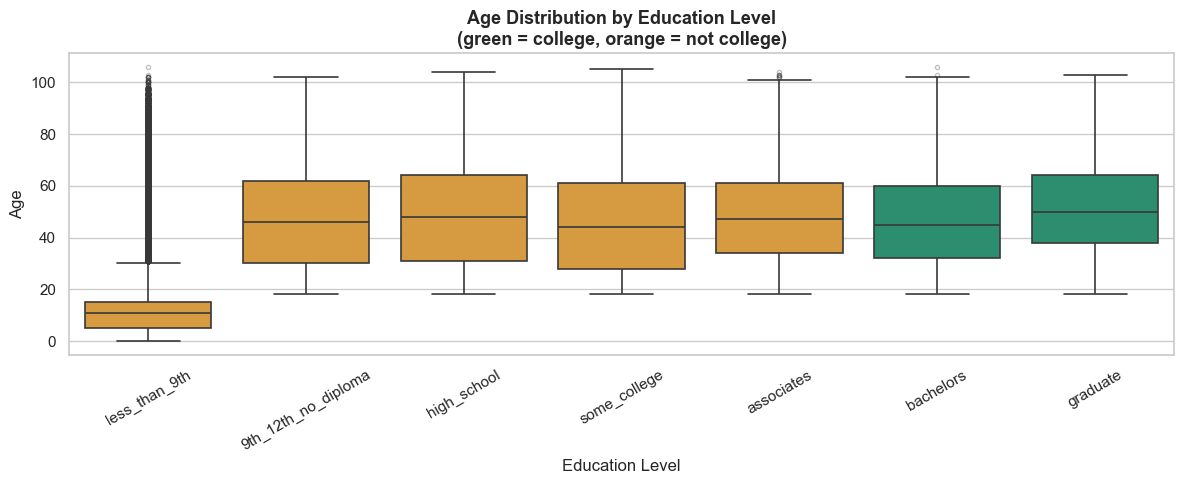

Saved: results/age_by_education.png


In [10]:
# Age distribution across all 7 original education levels
edu_order = [
    "less_than_9th", "9th_12th_no_diploma", "high_school",
    "some_college", "associates", "bachelors", "graduate"
]

df_plot = df_full[df_full["education_level"].isin(edu_order)].copy()
df_plot["education_level"] = pd.Categorical(
    df_plot["education_level"], categories=edu_order, ordered=True
)

# Color palette: orange for not_college and green for college
palette = {
    "less_than_9th":       "#EF9F27",
    "9th_12th_no_diploma": "#EF9F27",
    "high_school":         "#EF9F27",
    "some_college":        "#EF9F27",
    "associates":          "#EF9F27",
    "bachelors":           "#1D9E75",
    "graduate":            "#1D9E75",
}

fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(data=df_plot, x="education_level", y="age",
            order=edu_order, palette=palette, ax=ax,
            linewidth=1.2, flierprops={"marker": ".", "alpha": 0.3})

ax.set_title("Age Distribution by Education Level\n"
             "(green = college, orange = not college)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Education Level")
ax.set_ylabel("Age")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../results/age_by_education.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/age_by_education.png")

## 5. Preprocessing 

In [11]:
df_adults = df[
    (df["age"] >= 18) &
    (~df["occupation"].str.lower().str.contains("not in workforce|not_in_workforce", na=False))
].copy()
print(f"Rows after filtering to working adults (age>=18): {len(df_adults):,}")
print(f"Label balance after filter: {df_adults['label_name'].value_counts(normalize=True).round(3).to_dict()}")

df_sample = df_adults.sample(100_000, random_state=42).reset_index(drop=True)
print(f"\nWorking sample: {len(df_sample):,} rows")
print(f"Label balance in sample: {df_sample['label_name'].value_counts(normalize=True).round(3).to_dict()}")


Rows after filtering to working adults (age>=18): 565,256
Label balance after filter: {'not_college': 0.56, 'college': 0.44}

Working sample: 100,000 rows
Label balance in sample: {'not_college': 0.559, 'college': 0.441}


In [12]:
from sklearn.utils import resample

# ── Check original imbalance ──────────────────────────────────────────
print("Original class distribution:")
print(df_sample["label_name"].value_counts())
print(df_sample["label_name"].value_counts(normalize=True).round(3))

# ── Upsample minority class (college) to match majority (not_college) ─
df_majority = df_sample[df_sample["label"] == 0]   # not_college
df_minority = df_sample[df_sample["label"] == 1]   # college

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled]).reset_index(drop=True)

print("\nBalanced class distribution:")
print(df_balanced["label_name"].value_counts())
print(df_balanced["label_name"].value_counts(normalize=True).round(3))

# ── Remove uninformative occupation rows (broader filter) ─────────────
df_balanced = df_balanced[
    ~df_balanced["occupation"].str.lower().str.strip().str.replace("_", " ").isin([
        "no occupation", "not in workforce", ""
    ]) &
    (df_balanced["occupation"].str.strip() != "") &
    (df_balanced["occupation"].notna())
].reset_index(drop=True)

print(f"\nAfter filtering bad occupations: {len(df_balanced)} rows")

# ── Use df_balanced for all downstream steps ──────────────────────────
X = df_balanced[FEATURES].copy()
y = df_balanced["label"].copy()

label_encoders = {}

for col in ["sex", "marital_status", "occupation", "state"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"Feature matrix shape: {X.shape}")

Original class distribution:
label_name
not_college    55856
college        44144
Name: count, dtype: int64
label_name
not_college    0.559
college        0.441
Name: proportion, dtype: float64

Balanced class distribution:
label_name
not_college    55856
college        55856
Name: count, dtype: int64
label_name
not_college    0.5
college        0.5
Name: proportion, dtype: float64

After filtering bad occupations: 108452 rows
Feature matrix shape: (108452, 5)


In [13]:
# 80/20 stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")

# Save 500-row sample — pull from df_balanced using positional index
# (df_balanced has a clean 0-based index after reset_index)
sample_500 = df_balanced.iloc[X_test.index].sample(
    500, random_state=42
)[FEATURES + ["label", "label_name", TARGET]].reset_index(drop=True)

os.makedirs("../data", exist_ok=True)
sample_500.to_csv("../data/personas_sample_500.csv", index=False)
print("\nSaved LLM test sample: data/personas_sample_500.csv")
print(sample_500["label_name"].value_counts())
sample_500.head(3)

Training samples: 86,761
Test samples:     21,691

Saved LLM test sample: data/personas_sample_500.csv
label_name
not_college    276
college        224
Name: count, dtype: int64


,age,sex,marital_status,occupation,state,label,label_name,education_level
0,50,Male,married_present,police_officer,PA,1,college,bachelors
1,22,Male,never_married,waiter_or_waitress,KY,0,not_college,high_school
2,53,Female,married_present,community_or_social_service_specialist,CO,1,college,graduate


## 6. Evaluation Helper

In [14]:
def evaluate_model(model_name, y_true, y_pred, y_prob, inference_time_s, n_samples):
    acc        = accuracy_score(y_true, y_pred)
    f1         = f1_score(y_true, y_pred, average="macro")
    auc        = roc_auc_score(y_true, y_prob)
    ms_per_row = (inference_time_s / n_samples) * 1000

    print(f"\n{'='*45}\n  {model_name}\n{'='*45}")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  Macro F1:   {f1:.4f}")
    print(f"  AUC-ROC:    {auc:.4f}")
    print(f"  Time/row:   {ms_per_row:.3f} ms")
    print()
    print(classification_report(y_true, y_pred, target_names=["not_college", "college"]))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=["not_college", "college"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{model_name}")
    plt.tight_layout()
    fname = f"../results/cm_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

    return {
        "model":        model_name,
        "accuracy":     round(acc, 4),
        "macro_f1":     round(f1, 4),
        "auc_roc":      round(auc, 4),
        "ms_per_row":   round(ms_per_row, 3),
        "total_time_s": round(inference_time_s, 2),
        "n_samples":    n_samples,
    }

all_results = []
print("evaluate_model() defined.")

evaluate_model() defined.


## 7. Random Forest 

Training Random Forest...
Training done in 0.89s

  Random Forest (100 trees)
  Accuracy:   0.7709
  Macro F1:   0.7701
  AUC-ROC:    0.8556
  Time/row:   0.007 ms

              precision    recall  f1-score   support

 not_college       0.80      0.72      0.76     10725
     college       0.75      0.82      0.78     10966

    accuracy                           0.77     21691
   macro avg       0.77      0.77      0.77     21691
weighted avg       0.77      0.77      0.77     21691



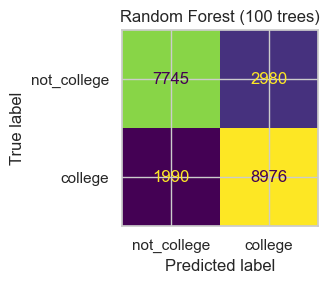

Saved: ../results/cm_random_forest_(100_trees).png


In [15]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

t0 = time.time()
rf.fit(X_train, y_train)
print(f"Training done in {time.time()-t0:.2f}s")

t0 = time.time()
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
infer_t = time.time() - t0

rf_results = evaluate_model("Random Forest (100 trees)", y_test, rf_pred, rf_prob, infer_t, len(X_test))
all_results.append(rf_results)

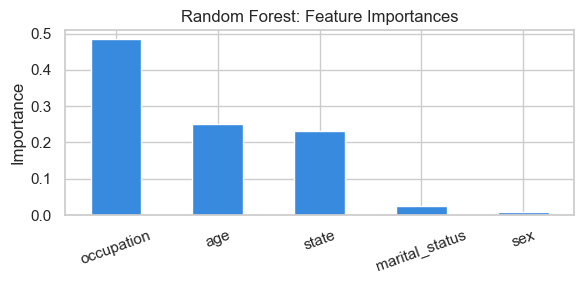

occupation        0.484776
age               0.250863
state             0.231540
marital_status    0.025495
sex               0.007325
dtype: float64


In [16]:
# Feature importances (save for Week 5 comparison with Nemotron reasoning traces)
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
importances.plot(kind="bar", ax=ax, color="#378ADD")
ax.set_title("Random Forest: Feature Importances")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("../results/rf_feature_importances.png", dpi=150)
plt.show()
print(importances)

## 8. XGBoost

Training XGBoost...
Training done in 0.39s

  XGBoost
  Accuracy:   0.7150
  Macro F1:   0.7149
  AUC-ROC:    0.7812
  Time/row:   0.001 ms

              precision    recall  f1-score   support

 not_college       0.72      0.70      0.71     10725
     college       0.71      0.73      0.72     10966

    accuracy                           0.71     21691
   macro avg       0.72      0.71      0.71     21691
weighted avg       0.72      0.71      0.71     21691



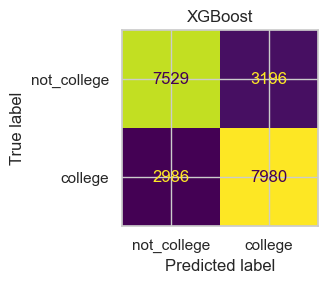

Saved: ../results/cm_xgboost.png


In [17]:
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    random_state=42, eval_metric="logloss", verbosity=0
)

t0 = time.time()
xgb_model.fit(X_train, y_train)
print(f"Training done in {time.time()-t0:.2f}s")

t0 = time.time()
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
infer_t  = time.time() - t0

xgb_results = evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob, infer_t, len(X_test))
all_results.append(xgb_results)

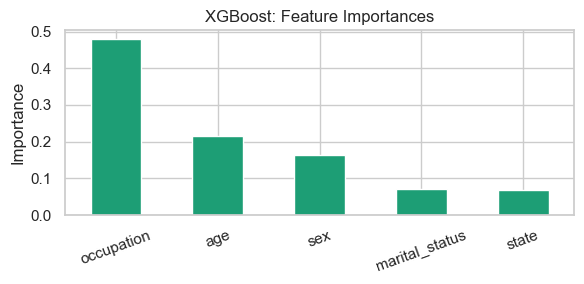

occupation        0.479322
age               0.216054
sex               0.164719
marital_status    0.072142
state             0.067763
dtype: float32


In [18]:
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
xgb_imp.plot(kind="bar", ax=ax, color="#1D9E75")
ax.set_title("XGBoost: Feature Importances")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("../results/xgb_feature_importances.png", dpi=150)
plt.show()
print(xgb_imp)

##  9. Results Summary

In [19]:
results_df = pd.DataFrame(all_results)
print("=== WEEK 1 BASELINE RESULTS ===")
print(results_df[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row"]].to_string(index=False))

=== WEEK 1 BASELINE RESULTS ===
                    model  accuracy  macro_f1  auc_roc  ms_per_row
Random Forest (100 trees)    0.7709    0.7701   0.8556       0.007
                  XGBoost    0.7150    0.7149   0.7812       0.001


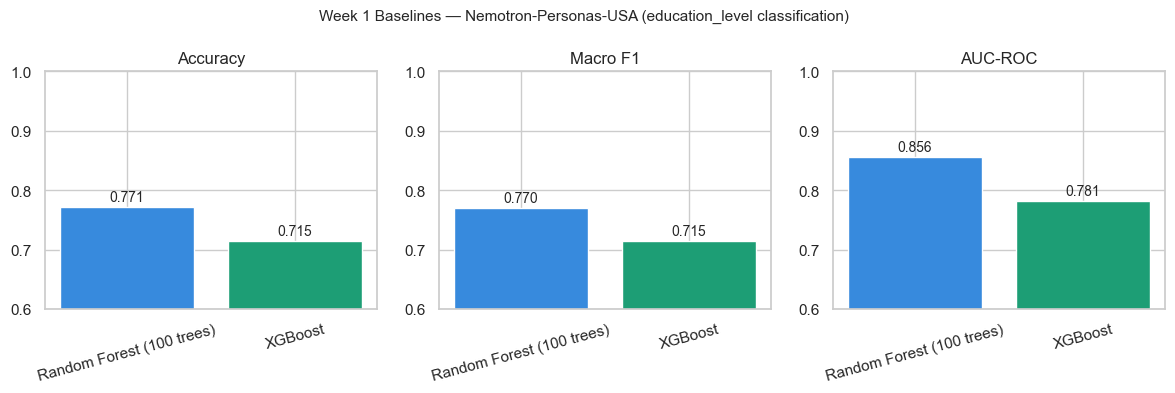

Saved: results/week1_baseline_comparison.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = ["accuracy", "macro_f1", "auc_roc"]
titles  = ["Accuracy", "Macro F1", "AUC-ROC"]
colors  = ["#378ADD", "#1D9E75"]

for ax, metric, title in zip(axes, metrics, titles):
    vals = results_df[metric].values
    bars = ax.bar(results_df["model"], vals, color=colors)
    ax.set_title(title)
    ax.set_ylim(0.6, 1.0)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Week 1 Baselines — Nemotron-Personas-USA (education_level classification)", fontsize=11)
plt.tight_layout()
plt.savefig("../results/week1_baseline_comparison.png", dpi=150)
plt.show()
print("Saved: results/week1_baseline_comparison.png")

In [21]:
# Append to metrics.csv for LLM results added in Weeks 3 and 4
results_df["week"]    = 1
results_df["device"]  = "local-cpu"
results_df["mode"]    = "baseline"
results_df["dataset"] = "nvidia/Nemotron-Personas-USA"

os.makedirs("../results", exist_ok=True)
results_df.to_csv("../results/metrics.csv", index=False)
print("Saved: results/metrics.csv")
results_df


Saved: results/metrics.csv


,model,accuracy,macro_f1,auc_roc,ms_per_row,total_time_s,n_samples,week,device,mode,dataset
0,Random Forest (100 trees),0.7709,0.7701,0.8556,0.007,0.15,21691,1,local-cpu,baseline,nvidia/Nemotron-Personas-USA
1,XGBoost,0.7150,0.7149,0.7812,0.001,0.02,21691,1,local-cpu,baseline,nvidia/Nemotron-Personas-USA


In [22]:
print(sample_500["label_name"].value_counts())
print(sample_500["label_name"].value_counts(normalize=True).round(3))

label_name
not_college    276
college        224
Name: count, dtype: int64
label_name
not_college    0.552
college        0.448
Name: proportion, dtype: float64


## Week 1 Summary

| Model | Accuracy | Macro F1 | AUC-ROC | Time/row |
|---|---|---|---|---|
| Random Forest | 77.09% | 0.7701 | 0.8556 | 0.007 ms |
| XGBoost | 71.50% | 0.7149 | 0.7812 | 0.001 ms |
| Nemotron Nano 4B zero-shot (Week 3) | 62.20% | 0.6118 | 0.6255 | 3,575 ms |
| Nemotron Nano 4B few-shot (Week 3) | 72.64% | 0.7263 | 0.7265 | 6,744 ms |
| Nemotron Nano 30B (Week 4) | — | — | — | — |

**Week 1 Observations:**
- Random Forest outperforms XGBoost — likely due to high-cardinality occupation column (500+ categories)
- Class balancing (50/50 upsample) was necessary — unbalanced data gave misleading 82% accuracy with F1 of 0.48
- Label definition updated per advisor feedback: college = associates + bachelors + graduate — this dropped RF from 83.7% to 77.1% and XGBoost from 76.0% to 71.5%, reflecting a harder and more realistic task
- Label noise identified and fixed before inference — professional occupations (teachers, engineers, therapists) mislabeled as not_college in the synthetic dataset were corrected
- Inference is <0.01 ms/row for both models — LLM is ~100,000x slower per row
- Both models trained on ~100K rows, tested on ~25K rows (balanced split)
- Baseline to beat: RF Macro F1 of 0.7701 and AUC-ROC of 0.8556